In [1]:
import numpy as np
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
from DESolver import DESolver

from problems_ODEs import ProblemsODE
from problems_PDEs import ProblemsPDE

import seaborn as sns
sns.set_context("talk", font_scale=1.) # "talk"
TEND=0.2
#KAPPA=np.asarray([1e+03,2e+03])
KAPPA=np.asarray([0.,0.])

CFL = 3.0
Solving Advection Reaction 1D Split by using ARK2c


/opt/local/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


Mass ini = 2.257499999999999 and mass end = 2.2575000000000687


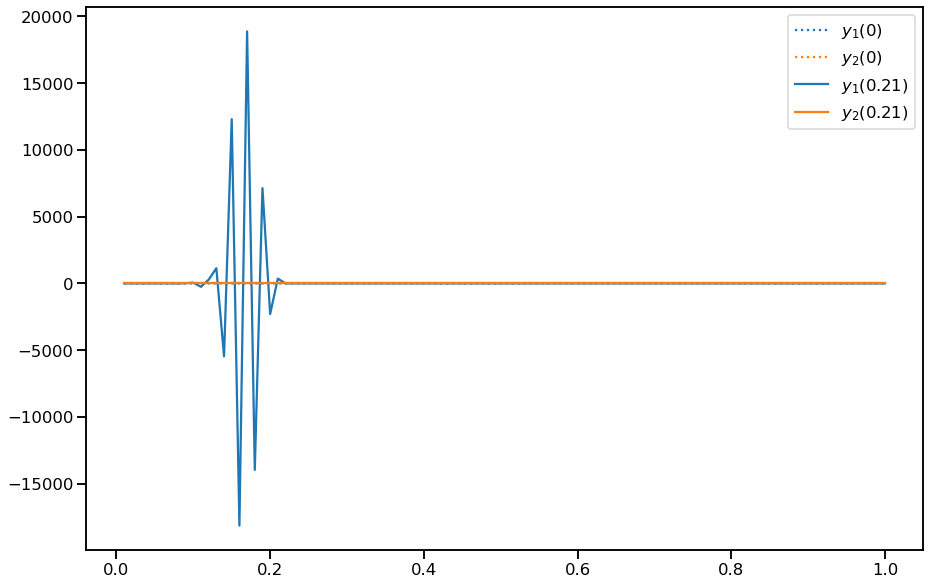

------------------------------------------
Current Method
Selected method type: ARK
Method coefficients:
A =
[[0.         0.         0.        ]
 [0.58578644 0.         0.        ]
 [0.5        0.5        0.        ]]
b =
[0.35355339 0.35355339 0.29289322]
c =
[0.         0.58578644 1.        ]
At =
[[0.         0.         0.        ]
 [0.29289322 0.29289322 0.        ]
 [0.35355339 0.35355339 0.29289322]]
bt =
[0.35355339 0.35355339 0.29289322]
ct =
[0.         0.58578644 1.        ]
------------------------------------------


In [12]:
solver=DESolver()
solver.set_info(0)

pde_problem_setup={'mx':100,'n':2,'Flux':'linear-advection','Flux_c':1.,'BC':'periodic',
                   'x_min':0.,'x_max':1.,'kappa':KAPPA,
                   's':np.asarray([0,0]),'alpha':np.asarray([1,0.]),'alpha_i':np.asarray([0,10.]),'Flux_name':'1stOrderUpwindFV'}
rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('Advection Reaction 1D Split',pde_problem_setup)#('Navier-Stokes2D')

solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)


solver.set_method('ARK2c')
#solver.set_method('ARK-IMEX-MR4')
#solver.set_method('ARK-IMEX-Mix-1-1')


if(rhs_i is not None):
    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
else:
    solver.set_rhs(rhs_e)
    
problem_setup['DT']=0.03    
problem_setup['T_DURATION']['end']=TEND


print("CFL = {:}".format(pde_problem_setup['Flux_c']*problem_setup['DT']/problem_setup['context']['dx']))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))

solver.solve()

t,u,_,_,_=solver.get_trajectory_GLEE()
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()

print("Mass ini = {:} and mass end = {:}".format(mass_ini,mass_end))



#sol=u
unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 10))
hy1=plt.plot(x_coord,y_ini[0,:],':',label=r'$y_1(0)$')
hy2=plt.plot(x_coord,y_ini[1,:],':',label=r'$y_2(0)$')

plt.plot(x_coord,y_end[0,:],'-',color=hy1[0].get_color(),label=r'$y_1({:g})$'.format(t[-1]))
plt.plot(x_coord,y_end[1,:],'-',color=hy2[0].get_color(),label=r'$y_2({:g})$'.format(t[-1]))

plt.legend()
plt.show()

solver.view_complete_status()

ARK11={'x_coord':x_coord,'y_end':y_end}
